In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
import pytorch_lightning as pl
from torch.utils.data import Dataset, Subset, DataLoader

from hierroute.constants import *
from hierroute.extra_functions import set_seed
from hierroute.data_setup import ImageDataset, HierImageDataset
from hierroute.hierarchy import Hierarchy
from hierroute import Trainer, HierRouteNet

/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
set_seed(SEED)

DataPath = '/Users/alexandermichaeltjhin/Everything/Repos/Zooplankton/data/WHOI-Plankton'
DataSubdirectory = [
    '2006','2007','2008','2009','2010','2011', '2012',
    '2013','2014']
adj_graph = whoi_adjacency_graph_s
RESOLUTION = 65

SELECTED_LIST = [key for key, item in adj_graph.items() if len(item) == 0]

dataset = ImageDataset(
    data_directory = '/Users/alexandermichaeltjhin/Everything/Repos/Zooplankton/data/WHOI-Plankton',
    data_subdirectories = DataSubdirectory,
    class_names = SELECTED_LIST,
    max_class_size = 6000,
    image_resolution = 64,
    image_transforms = None,
    format_file = '.png',
    seed = SEED,
    class_folder_map={                                                                                                                                             
          'Guinardia': ['Guinardia_delicatula', 'Guinardia_flaccida', 'Guinardia_striata']
      }
    )

whoi_dataset = HierImageDataset(
    base_dataset=dataset,
    adjacency_graph = adj_graph,
    levels=3,
    leaves_only=True
)
whoi_dataset.print_dataset_details()

[leaves_only] Kept 69150 samples | Removed 0 non-leaf samples

Total Dataset: Size = 69150 | Levels = 3
all_node_counts: {0: 69150, 1: 50646, 3: 8148, 7: 6000, 8: 295, 9: 1853, 4: 42498, 10: 4307, 11: 6000, 12: 2191, 13: 6000, 14: 6000, 15: 6000, 16: 6000, 17: 6000, 2: 18504, 5: 11160, 18: 5999, 19: 5161, 6: 7344, 20: 6000, 21: 711, 22: 633}

nodes_by_level: {0: [0], 1: [1, 2], 2: [3, 4, 5, 6], 3: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]}


------------------------Level 0------------------------
Level: 0 | Class Name: root                 | Class Label:   0 | Type: Parent | Count:  69150 | Prop: 1.00

------------------------Level 1------------------------
Level: 1 | Class Name: Colonial             | Class Label:   1 | Type: Parent | Count:  50646 | Prop: 0.73
Level: 1 | Class Name: Unicellular          | Class Label:   2 | Type: Parent | Count:  18504 | Prop: 0.27

------------------------Level 2------------------------
Level: 2 | Class Name: C-Spines            

In [4]:
from torch.utils.data import Dataset, Subset, DataLoader, SequentialSampler, WeightedRandomSampler, random_split
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.Pad(padding = 5, fill = 0),
    transforms.Resize((RESOLUTION, RESOLUTION)),
    transforms.ToTensor(),
])


whoi_dataset.append_image_transforms(
    image_transforms = train_transforms, replace = True
)

TRAIN_PROP = 0.7
VAL_PROP = 0.1
TEST_PROP = 0.2

BATCH_SIZE = 64

train_split, val_split, test_split = whoi_dataset.split_train_test_val(
    train_prop = TRAIN_PROP, val_prop = VAL_PROP, test_prop = TEST_PROP
)

# Create dataloaders
train_loader, val_loader, test_loader = whoi_dataset.create_dataloaders(
    batch_size = BATCH_SIZE,
    train_indices = train_split,
    val_indices = val_split,
    test_indices = test_split,
    image_transforms = None,
    train_sample_weights = None,
    balanced=True
)


In [ ]:
import time
from datetime import date



today = date.today()

if torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f'Using device: MPS (Apple Silicon GPU)')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Using device: CUDA GPU')
else:
    device = torch.device('cpu')
    print(f'Using device: CPU')
backbone = "swin_t"
# backbone = "efficientnet_b0"
expert_type="mlp"
model = HierRouteNet(whoi_dataset.hierarchy, whoi_dataset.label_to_ids,
                #    loss_type = "focal", 
                   backbone= backbone, 
                   freeze_backbone=False,
                   expert_type=expert_type)
HYPERPARAMETERS = {
    'lr': 3e-4, 
    'epochs': 40, 
    'scheduler':True,
    'early_stopping': {'patience': 5, 'delta': 0.001},
}
start = time.time()
trainer = Trainer(learning_rate=HYPERPARAMETERS['lr'], max_epochs=HYPERPARAMETERS['epochs'], device=device,
                  print_every=1, model_dir=f"{backbone}_whoi_{expert_type}_{today}")
trainer.fit(model, train_loader, val_loader, scheduler=HYPERPARAMETERS['scheduler'],
            patience=HYPERPARAMETERS['early_stopping']['patience'],
            delta=HYPERPARAMETERS['early_stopping']['delta'])
print(f"Total time taken {round((time.time() - start) / 60, 2)} minutes")

Using device: MPS (Apple Silicon GPU)
Total time taken 0.0 minutes


In [18]:
# saved_dir = "efficient_net_whoi_2026-03-11_2"
print(f"loading from {trainer.model_dir}")
model = HierRouteNet(whoi_dataset.hierarchy, whoi_dataset.label_to_ids, checkpoint_dir=trainer.model_dir,
                   backbone= backbone, expert_type=expert_type)
result = trainer.predict(model, test_loader, save=True)

loading from swin_t_whoi_mlp_2026-03-30
Loaded checkpoint: swin_t_whoi_mlp_2026-03-30/best_model.pt
Hierarchical Evaluation:
  Level 1: Acc=0.9849 | F1=0.9808 | Prec=0.9794 | Rec=0.9821 | n=13830
    Colonial               Acc=0.9881 | F1=0.9897 | Prec=0.9913 | Rec=0.9881 | n=10129
    Unicellular            Acc=0.9762 | F1=0.9719 | Prec=0.9676 | Rec=0.9762 | n=3701
  Level 2: Acc=0.9748 | F1=0.9682 | Prec=0.9673 | Rec=0.9692 | n=13830
    C-Spines               Acc=0.9448 | F1=0.9477 | Prec=0.9506 | Rec=0.9448 | n=1630
    C-NoSpines             Acc=0.9801 | F1=0.9814 | Prec=0.9828 | Rec=0.9801 | n=8499
    U-Spines               Acc=0.9749 | F1=0.9693 | Prec=0.9637 | Rec=0.9749 | n=2232
    U-NoSpines             Acc=0.9769 | F1=0.9745 | Prec=0.9722 | Rec=0.9769 | n=1469
  Level 3: Acc=0.9221 | F1=0.9165 | Prec=0.9081 | Rec=0.9259 | n=13830
    Chaetoceros            Acc=0.9292 | F1=0.9409 | Prec=0.9530 | Rec=0.9292 | n=1200
    Lauderia               Acc=0.8814 | F1=0.8189 | Prec=0.

In [10]:
from hierroute import Visualize

Saved → training_result/whoi/swin_t_whoi_cnn/train_metrics.png


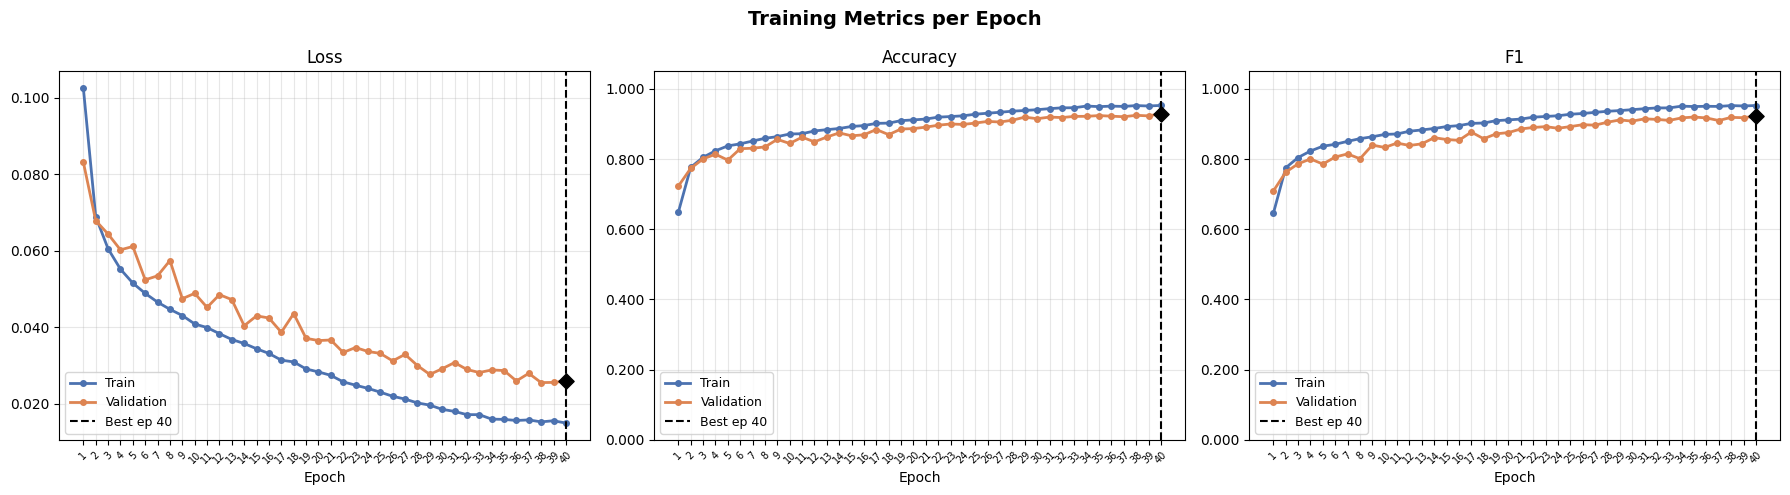

In [11]:
# path = trainer.model_dir
# path = "swin_t_mlp_2026-03-27"
path = "training_result/whoi/swin_t_whoi_cnn"
vis = Visualize(path)
vis.plot_train()

Saved → training_result/whoi/swin_t_whoi_cnn/confusion_matrix_level1.png


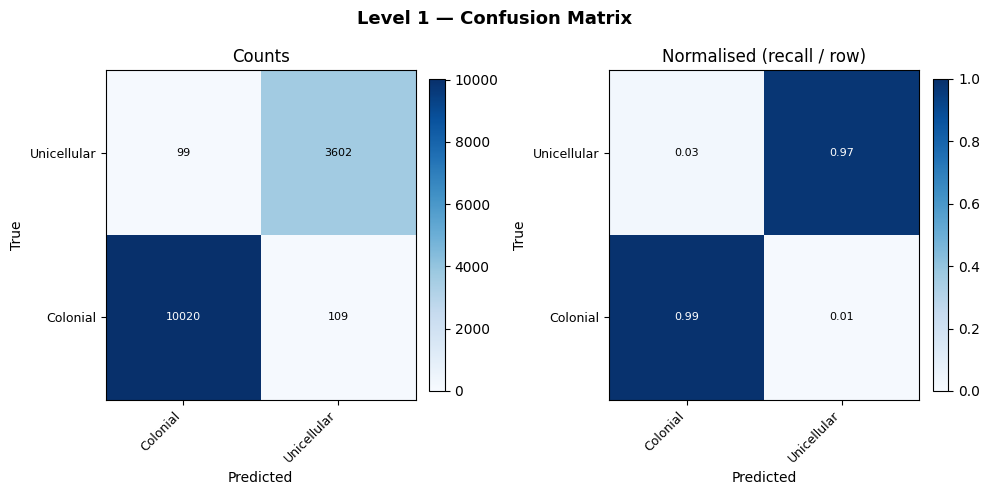

Saved → training_result/whoi/swin_t_whoi_cnn/class_metrics_level1.png


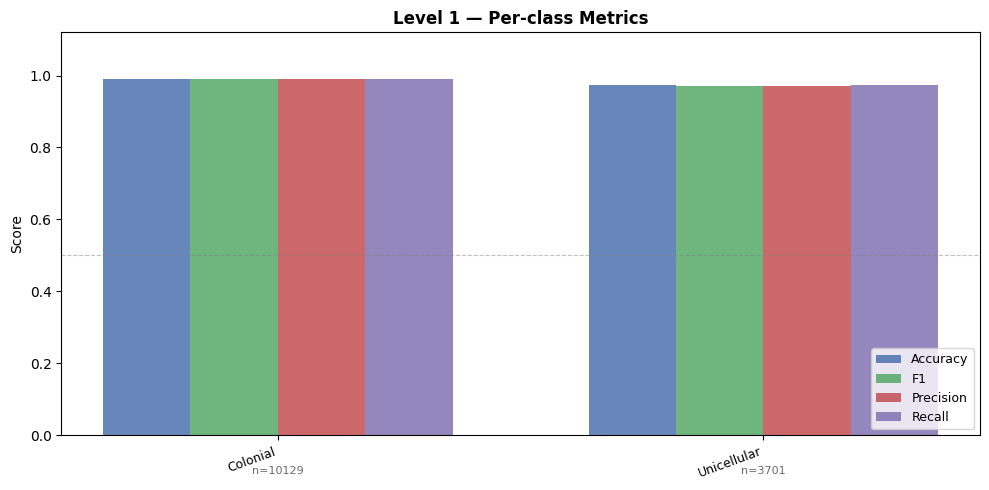

Saved → training_result/whoi/swin_t_whoi_cnn/confusion_matrix_level2.png


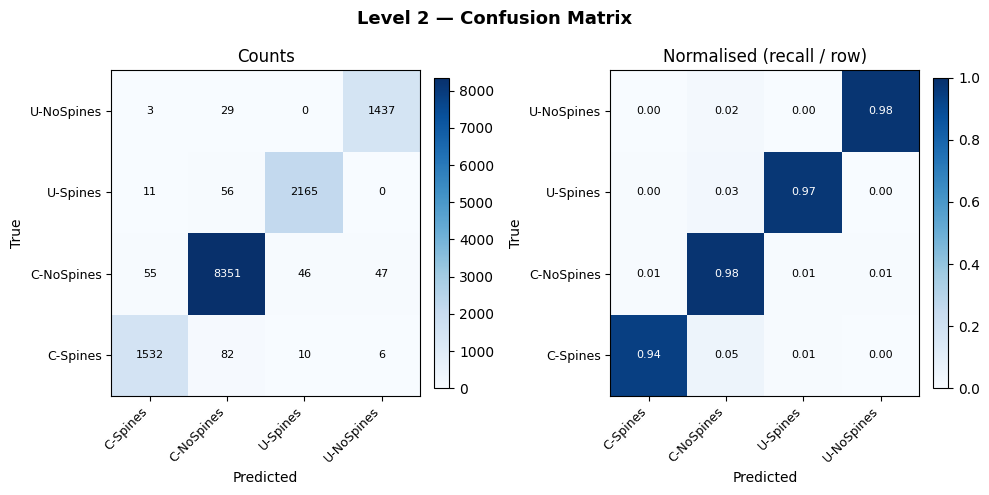

Saved → training_result/whoi/swin_t_whoi_cnn/class_metrics_level2.png


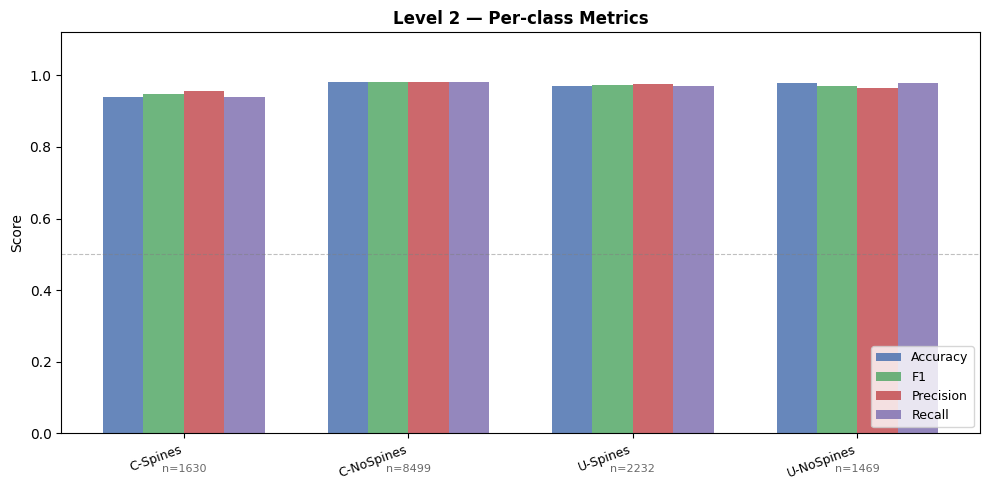

Saved → training_result/whoi/swin_t_whoi_cnn/confusion_matrix_level3.png


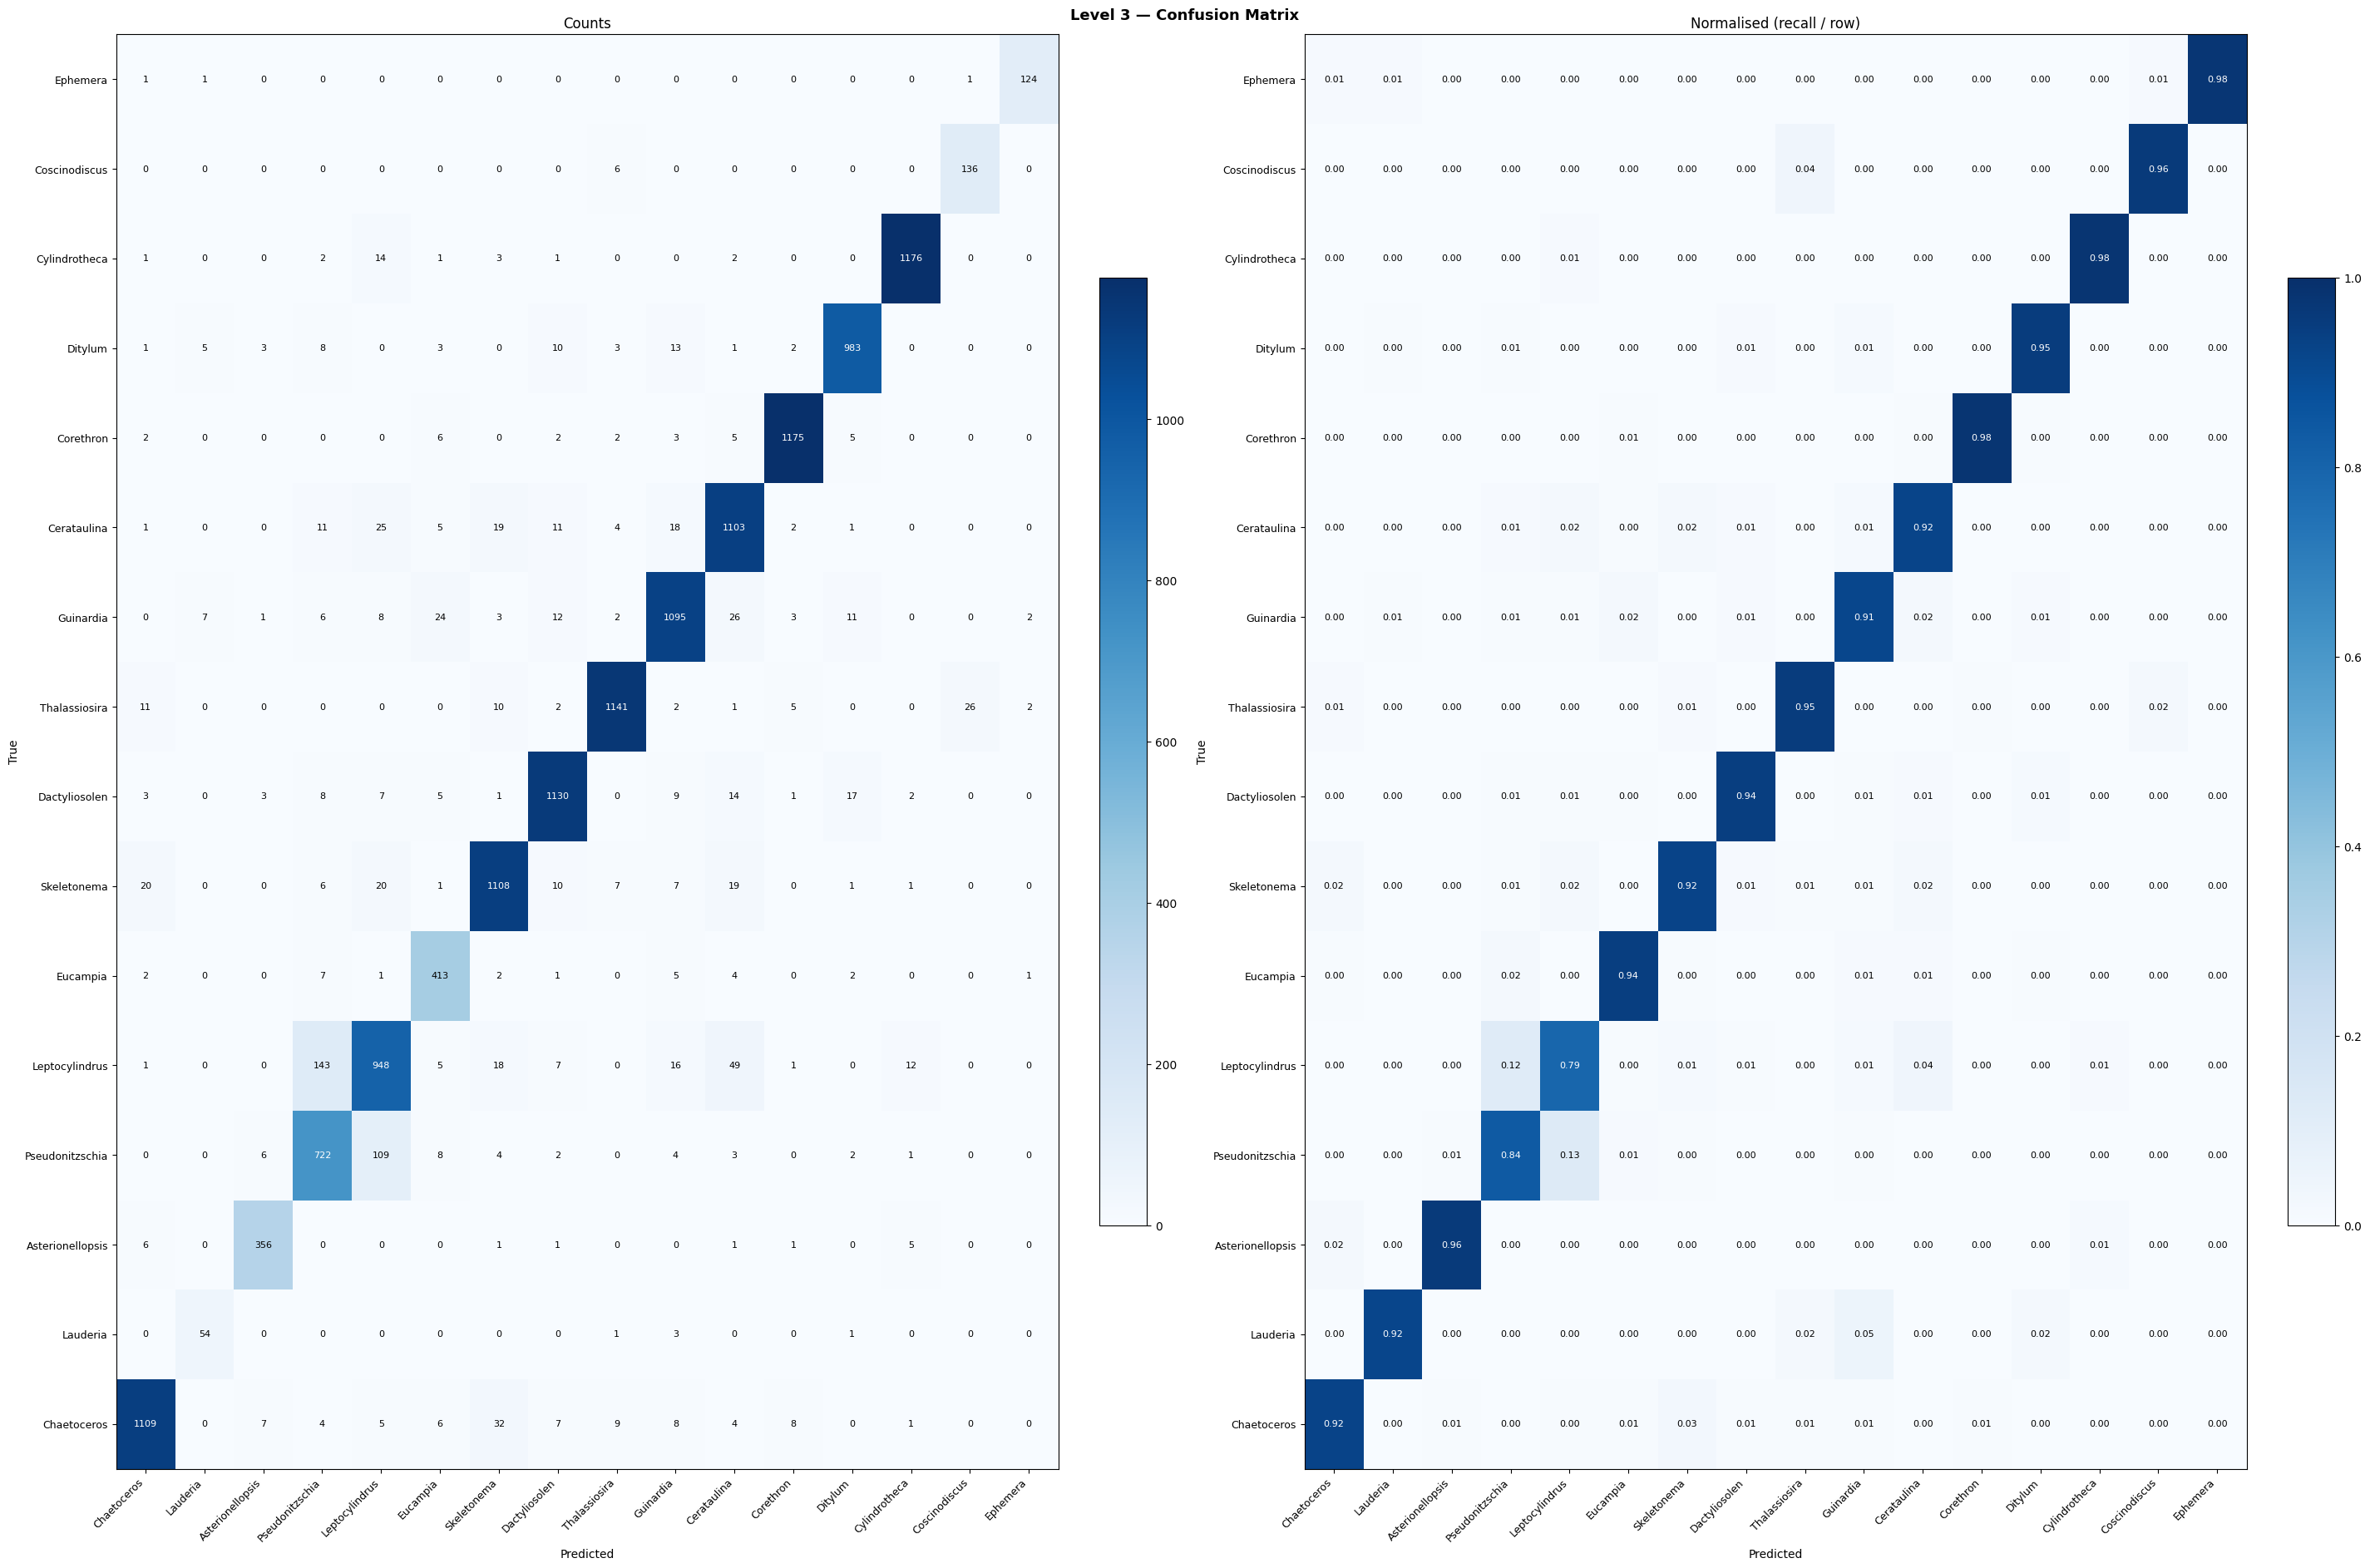

Saved → training_result/whoi/swin_t_whoi_cnn/class_metrics_level3.png


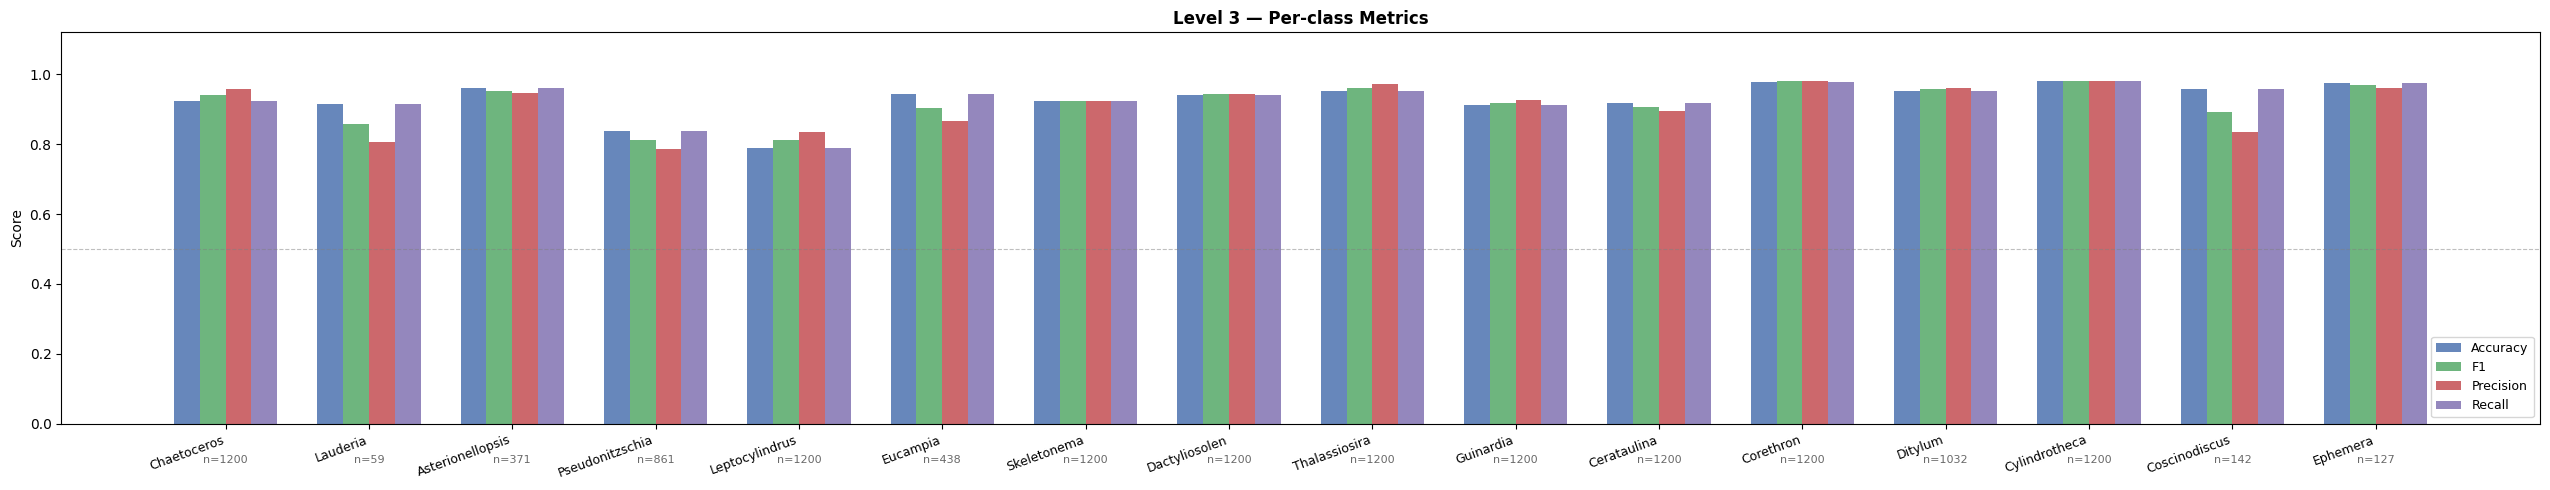

Saved → training_result/whoi/swin_t_whoi_cnn/level_comparison.png


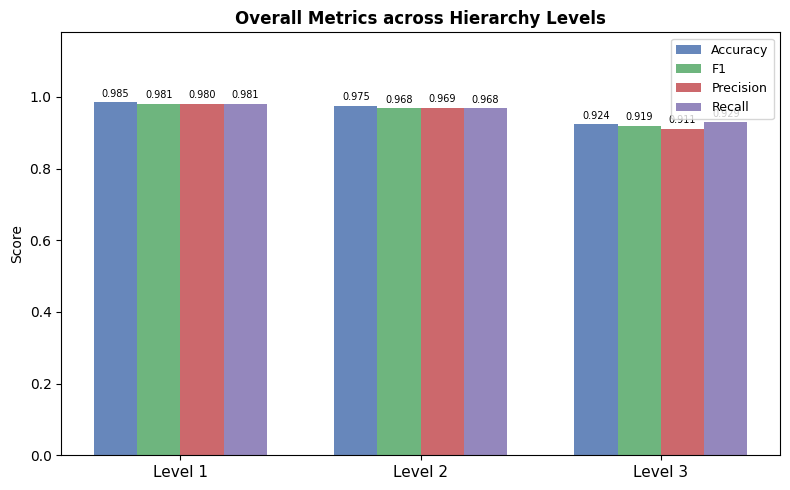

In [12]:
vis.plot_pred()

Saved → training_result/whoi/swin_t_whoi_cnn/level_comparison.png


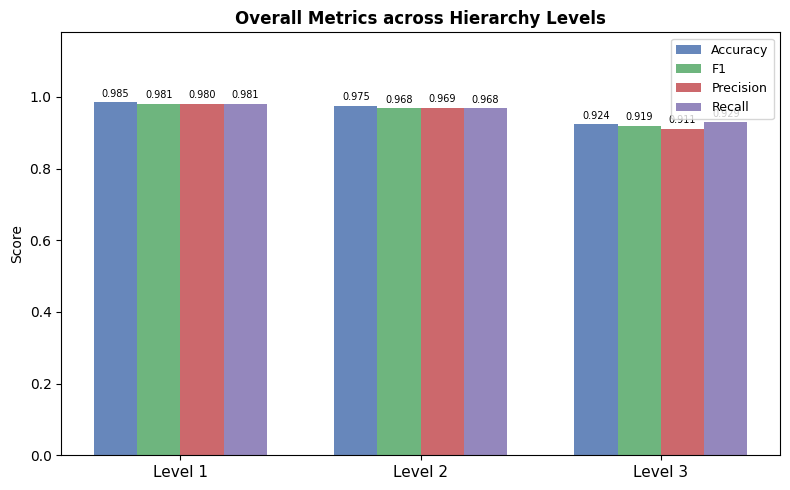

In [13]:
vis.plot_level_comparison()

Saved → training_result/whoi/swin_t_whoi_cnn/size_vs_accuracy.png


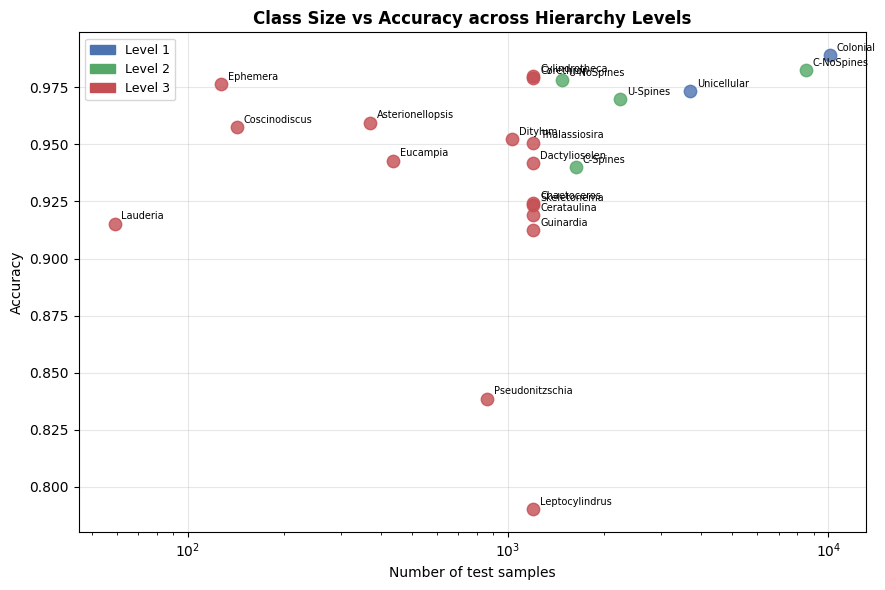

In [14]:
vis.plot_class_size_vs_accuracy()

In [17]:
saved_dir = "training_result/whoi/swin_t_whoi_cnn"        
backbone = 'swin_t'
expert_type = "cnn"
model = HierRouteNet(whoi_dataset.hierarchy, whoi_dataset.label_to_ids, checkpoint_dir=saved_dir,
                   backbone= backbone, expert_type=expert_type)     

Loaded checkpoint: training_result/whoi/swin_t_whoi_cnn/best_model.pt


In [28]:
model.shared[1]

Sequential(
  (0): SwinTransformerBlock(
    (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (attn): ShiftedWindowAttention(
      (qkv): Linear(in_features=96, out_features=288, bias=True)
      (proj): Linear(in_features=96, out_features=96, bias=True)
    )
    (stochastic_depth): StochasticDepth(p=0.0, mode=row)
    (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (mlp): MLP(
      (0): Linear(in_features=96, out_features=384, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.0, inplace=False)
      (3): Linear(in_features=384, out_features=96, bias=True)
      (4): Dropout(p=0.0, inplace=False)
    )
  )
  (1): SwinTransformerBlock(
    (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (attn): ShiftedWindowAttention(
      (qkv): Linear(in_features=96, out_features=288, bias=True)
      (proj): Linear(in_features=96, out_features=96, bias=True)
    )
    (stochastic_depth): StochasticDepth(p=0.01818181818181818

In [40]:
model.shared[5][-1]

SwinTransformerBlock(
  (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
  (attn): ShiftedWindowAttention(
    (qkv): Linear(in_features=384, out_features=1152, bias=True)
    (proj): Linear(in_features=384, out_features=384, bias=True)
  )
  (stochastic_depth): StochasticDepth(p=0.16363636363636364, mode=row)
  (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
  (mlp): MLP(
    (0): Linear(in_features=384, out_features=1536, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=1536, out_features=384, bias=True)
    (4): Dropout(p=0.0, inplace=False)
  )
)

Loaded checkpoint: training_result/whoi/swin_t_whoi_cnn/best_model.pt
Saved → training_result/whoi/swin_t_whoi_cnn/attention_map.png


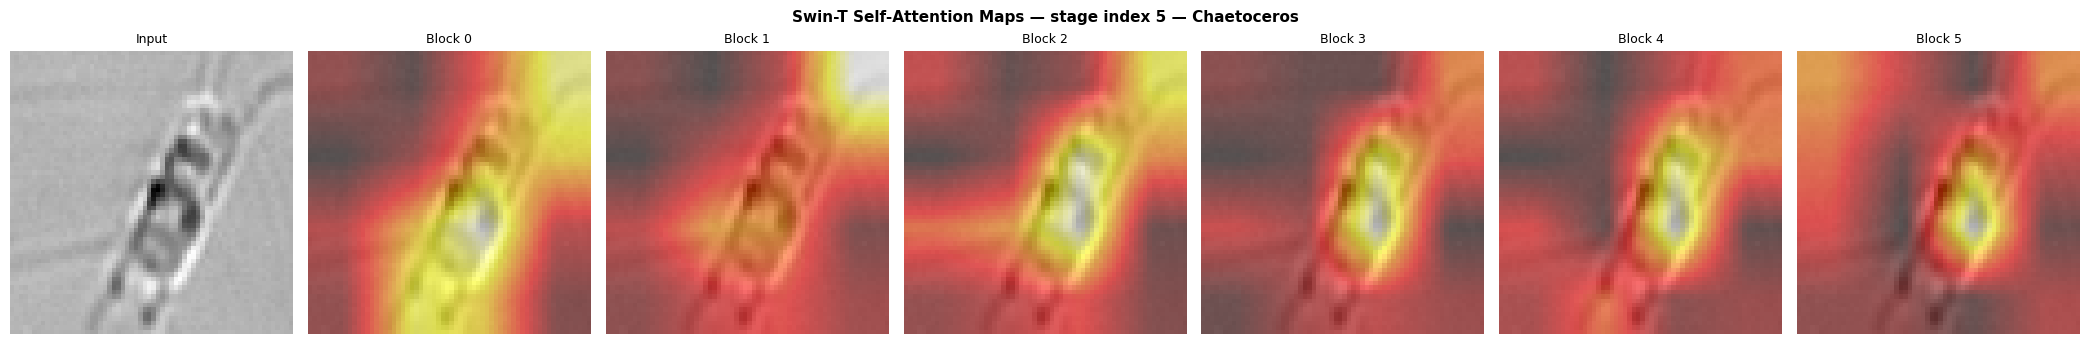

In [41]:
from hierroute import visualize_swin_attention                                                                                                                                                
from torchvision import transforms                                                                                                                                                            
from PIL import Image                                                                                                                                                                         

saved_dir ="training_result/whoi/swin_t_whoi_cnn"     
backbone = 'swin_t'
expert_type = "cnn"
model = HierRouteNet(whoi_dataset.hierarchy, whoi_dataset.label_to_ids, checkpoint_dir=saved_dir,
                   backbone= backbone, expert_type=expert_type)                                                                                                                                                
idx = test_split[0]                                                                                                                                                                           
sample_path = whoi_dataset.image_paths[idx]                                                                                                                                                   
                                                                                                                                                                                                
label_id   = whoi_dataset.labels[idx]                                                                                                                                                         
label_name = {v: k for k, v in whoi_dataset.label_to_ids.items()}[label_id]
img = Image.open(sample_path).convert('L')
img_tensor = transforms.Compose([                                                                                                                                                             
    transforms.Resize((64, 64)),                                                                                                                                                            
    transforms.ToTensor(),                                                                                                                                                                    
])(img).unsqueeze(0).repeat(1, 3, 1, 1)   # (1, 3, 64, 64)                                                                                                                                  
                                                                                                                                                                                            
fig = visualize_swin_attention(model, img_tensor, stage=5,
                                label=label_name,
                                save_path=f"{saved_dir}/attention_map.png")  
                                